In [24]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [3]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)
filename = './crs/IST-Lisbon.txt'
IST = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(datasets)

In [53]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

Excitation, level 4
11.8
Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross sections of Ar. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(9), 1785–1801. https://doi.org/10.1088/0953-4075/29/9/022
15.071227991895011
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H

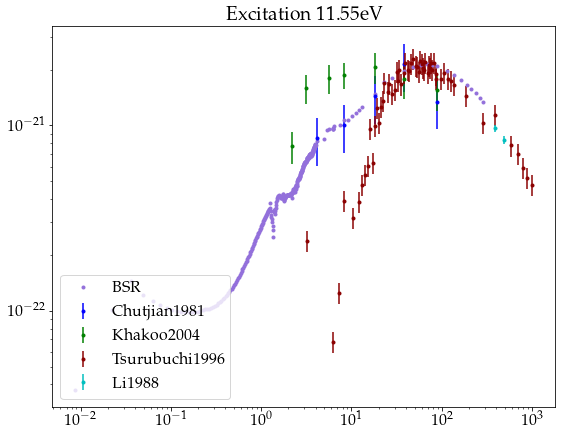

In [258]:
from models import *
level = 4
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0
print('Excitation, level '+str(level))
print(threshold)

targetrefs = []

# W = None
W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
#         if (W is None):
#             W = np.copy(temp)
#         else:
#             W = np.append( W, temp, axis=0)

#         filename = '../crs-exp/excitation-level4/crs.%s.txt' % (refs[k])
#         np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold + 0.1)):
        targetrefs += ['BSR']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
#         print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
#         W = np.append( W, temp, axis=0)

for c in IST.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold + 0.1)):
        temp1 = np.copy(c.data[1:,:])
        error = temp1[:,1][...,None] * 0.01
        temp1 = np.append( temp1, error, axis=1)
#         print(c.deltaE)

# mask = W[:,0] - E_ext[level-1] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([2.54e0,1])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
# model0 = Excite_resonance(4,theta_ref,Etest)
# mask = model0 > 1.0e-23
# Etest = Etest[mask]
# model0 = model0[mask]
plt.figure(1)
for k, Wk in enumerate(W):
    if(k==4):
        plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
    else:
        plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
# plt.plot(Etest[mask]-E_ext[3],model0[mask],'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()

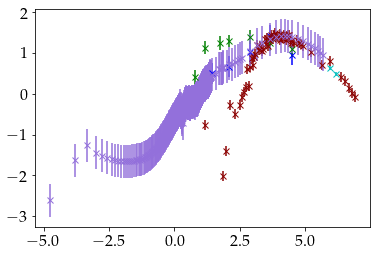

In [259]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [torch.Tensor(temp)]

# Wlog = Wlog[:2] + Wlog[3:]
    
Wlogm, Nw = 0.0, 0
for wlogk in Wlog:
    Nw += wlogk.size(0)
    Wlogm += wlogk[:,1].sum()
Wlogm /= Nw

for k, wlogk in enumerate(Wlog):
    wlogk[:,1] -= Wlogm


# Wlogm = []
# for wlogk in Wlog:
# #     Nw += wlogk.size(0)
#     Wlogm += [wlogk[:,1].mean()]
# # Wlogm /= Nw

# for k, wlogk in enumerate(Wlog):
#     wlogk[:,1] -= Wlogm[k]
    
# Wlog = [Wlog[-3]]
    
# for k, wlogk in enumerate(Wlog):
#     if(k==0):
#         wlogx = torch.clone(wlogk[:,0])
#         wlogy = torch.clone(wlogk[:,1])
#         wloge = torch.clone(wlogk[:,2])
#         wlogt = torch.clone(wlogk)
#     else:
#         wlogx = torch.cat((wlogx,wlogk[:,0]),-1)
#         wlogy = torch.cat((wlogy,wlogk[:,1]),-1)
#         wloge = torch.cat((wloge,wlogk[:,2]),-1)
#         wlogt = torch.cat((wlogt,wlogk),0)

# print(wlogt.size())
# Wlog = [wlogt]
        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])

In [260]:
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0].repeat(wlogk.size(0),1)
    xd += [temp - temp.t()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]

class ExpKernel(torch.nn.Module):
    def __init__(self):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, xd):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return self.var * torch.exp( - xd ** 2 / self.scale )
    
    def covariance(self, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        return self.var * torch.exp( - xd ** 2 / self.scale )
    
class ExpKernelPack(torch.nn.Module):
    def __init__(self,n=1):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.n = n
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(n))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(n))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, n, xd):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return self.var[n] * torch.exp( - xd ** 2 / self.scale[n] )
    
    def covariance(self, n, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        return self.var[n] * torch.exp( - xd ** 2 / self.scale[n] )
    
class MaternPack(torch.nn.Module):
    def __init__(self,n,nu=1.5):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        if nu not in {0.5, 1.5, 2.5}:
            raise RuntimeError("nu expected to be 0.5, 1.5, or 2.5")
        super().__init__()
        self.nu = nu
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(n))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(n))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, n, xd):
        import math
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        expComponent = torch.exp( - math.sqrt(self.nu * 2) * torch.abs(xd) / self.scale[n] )
        
        if (self.nu == 0.5):
            constant_component = 1.0
        elif (self.nu == 1.5):
            constant_component = 1.0 + math.sqrt(3) * torch.abs(xd) / self.scale[n]
        elif (self.nu == 2.5):
            constant_component = 1.0 + math.sqrt(5) * torch.abs(xd) / self.scale[n] + 5.0 / 3.0 * torch.abs(xd) ** 2 / (self.scale[n]**2)
        return self.var[n] * constant_component * expComponent
    
    def covariance(self, n, x1, x2):
        import math
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        
        expComponent = torch.exp( - math.sqrt(self.nu * 2) * torch.abs(xd) / self.scale[n])
        
        if (self.nu == 0.5):
            constant_component = 1.0
        elif (self.nu == 1.5):
            constant_component = 1.0 + math.sqrt(3) * torch.abs(xd) / self.scale[n]
        elif (self.nu == 2.5):
            constant_component = 1.0 + math.sqrt(5) * torch.abs(xd) / self.scale[n] + 5.0 / 3.0 * torch.abs(xd) ** 2 / (self.scale[n]**2)
        return self.var[n] * constant_component * expComponent
    
class ExpTanhKernel(torch.nn.Module):
    def __init__(self):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var1 = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var2 = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.slope = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.phase = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var.clamp(min=0.0)
        self.var1.clamp(min=0.0)
        self.var2.clamp(min=0.0)
        self.scale.clamp(min=0.0)
        self.slope.clamp(min=-2.0,max=2.0)

    def forward(self, xd, xm):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        TanhFactor = 0.5 * (self.var1 + self.var2) + 0.5 * (self.var2 - self.var1) * torch.tanh( self.slope * (xm - self.phase) )
        return self.var * torch.exp( - xd ** 2 / self.scale ) + torch.diag(TanhFactor)
#         return self.var * torch.exp( - xd ** 2 / self.scale ) * TanhFactor
    
    def covariance(self, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xx1 = x1.repeat(x2.size(0),1).t()
        xx2 = x2.repeat(x1.size(0),1)
        xd = xx1 - xx2
#         xm = 0.5 * (xx1 + xx2)
        xm = torch.clone(xx1)
        xm[xx1!=xx2] = 0.0
        TanhFactor = 0.5 * (self.var1 + self.var2) + 0.5 * (self.var2 - self.var1) * torch.tanh( self.slope * (xm - self.phase) )
        temp = self.var * torch.exp( - xd ** 2 / self.scale )
        print(temp.size(),TanhFactor.size())
        return self.var * torch.exp( - xd ** 2 / self.scale ) + torch.diag(TanhFactor)
#         return self.var * torch.exp( - xd ** 2 / self.scale ) * TanhFactor
        

In [214]:
# cov_kern = ExpKernelPack(len(Wlog))
cov_kern = MaternPack(len(Wlog))

optimizer = torch.optim.LBFGS(cov_kern.parameters(),lr=1e-4)

def logLikelihood(kernels):
    lk = 0.0
    
    for k in range(len(Wlog)):
        cov = kernels.forward(k, xd[k])
#         print(cov)
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk += - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
    return - lk        

def likelihoodEntropy(kernels):
    ent = 0.0
    
    for k in range(len(Wlog)):
        cov = kernels.forward(k, xd[k])
#         cov = kernel.forward(xd[k],xm[k])
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk = - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
#         if (k==2): lk *= 0.2
        ent += lk * torch.exp(lk)
    return ent

def closure():
#     lk = logLikelihood(cov_kern)
    lk = likelihoodEntropy(cov_kern)
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
#     lk = logLikelihood(cov_kern)
    lk = likelihoodEntropy(cov_kern)
    if t % 100 == 99:
        print(t, lk.item())

    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
for name, param in cov_kern.named_parameters():
    if param.requires_grad:
        print(name, param.data)

99 -0.4190625250339508
199 -0.4190625250339508
299 -0.4190625250339508
399 -0.4190625250339508
499 -0.4190625250339508
599 -0.4190625250339508
699 -0.4190625250339508
799 -0.4190625250339508
899 -0.4190625250339508
999 -0.4190625250339508
var tensor([0.8048, 1.0886, 0.1364, 0.8881, 1.0893])
scale tensor([0.9559, 0.9355, 0.7623, 0.9520, 0.9550])


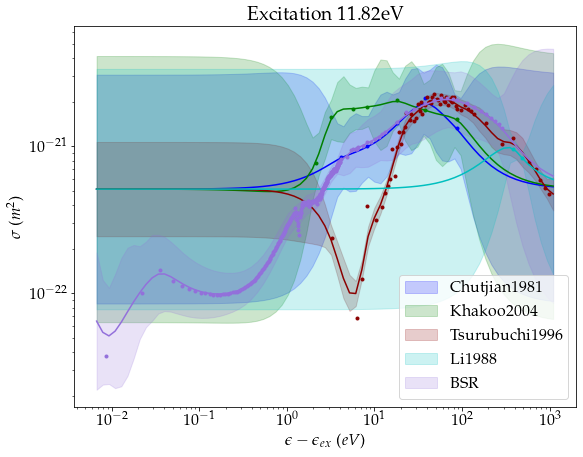

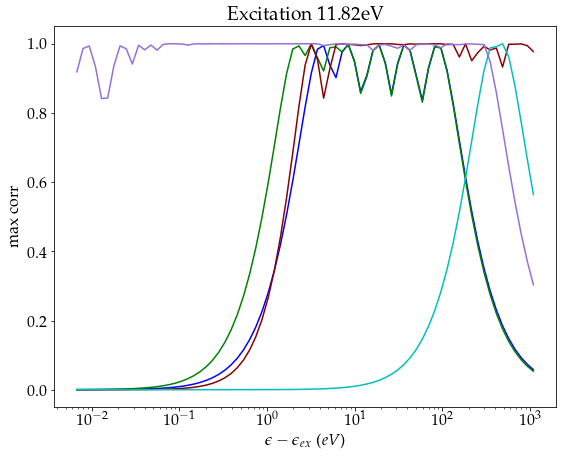

In [231]:
def max_corr(kernels,n,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
#     for k in range(kernels.n):
    varm = kernels.forward(n, xm-xm)
    vart = kernels.forward(n, xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernels.covariance(n,xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

xtest = torch.linspace(-5,7,75)

Kb, Kp = [], []
for k in range(len(Wlog)):
    cov = cov_kern.forward(k,xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    cov += torch.diag(ed[k]**2)
    Kb += [cov]
    Kp += [cov_kern.covariance(k,xm[k],xtest)]
# Kb = torch.block_diag(*Kd)
# Kp = cov_kern.covariance(wlogx,xtest)
# print(Kb.size(),Kp.size())

ym, y_var, zm = [], [], []
y_cov = []
for k in range(len(Wlog)):
    LKb = torch.cholesky(Kb[k])
    ym += [torch.matmul( Kp[k].t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()]
    y_cov += [cov_kern.covariance(k,xtest,xtest) - torch.matmul( Kp[k].t(), torch.cholesky_solve(Kp[k],LKb) ) ]
    y_var += [torch.diag(y_cov[k])]
    zm += [max_corr(cov_kern,k,xm[k],xtest)]
# print(y_var)
# print((ym + torch.sqrt(y_var)).size())
# print(cov_kern.var,cov_kern.scale)
# print(cov_kern.var1,cov_kern.var2,cov_kern.slope,cov_kern.phase)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k!=3)): continue
#     plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x')
    plt.plot(np.exp(wlogk[:,0]),np.exp(wlogk[:,1]+Wlogm),'.',color=colors[k])
    plt.plot(np.exp(xtest),np.exp(ym[k].detach()+Wlogm),'-',color=colors[k])
    plt.fill_between(
        np.exp(xtest),
        # plus/minus standard deviation (70 percent confidence interval)
        np.exp((ym[k] - 2.0 * torch.sqrt(y_var[k])).detach() + Wlogm),
        np.exp((ym[k] + 2.0 * torch.sqrt(y_var[k])).detach() + Wlogm),
        alpha=0.2,
        color=colors[k],
        label=targetrefs[k],
    )
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon - \epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^{2}$)')
plt.title('Excitation 11.82eV')
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset6.pdf", dpi=600)
    
plt.figure(2)
for k, wlogk in enumerate(Wlog):
#     if((k!=0) and (k!=1)): continue
    plt.plot(np.exp(xtest),zm[k].detach(),'-',color=colors[k])
plt.xscale('log')
plt.xlabel('$\epsilon - \epsilon_{ex}$ ($eV$)')
plt.ylabel('max corr')
plt.title('Excitation 11.82eV')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset7.pdf", dpi=600)

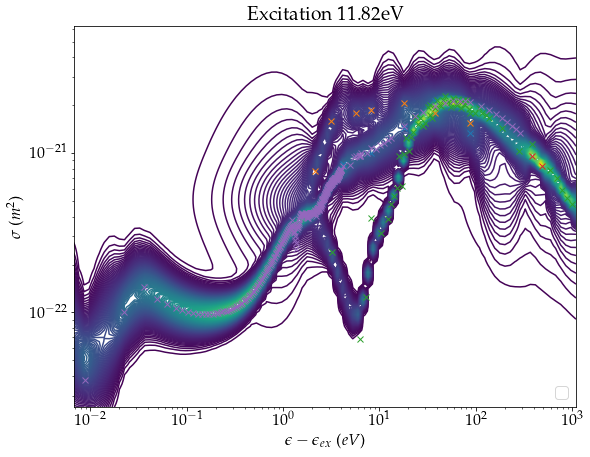

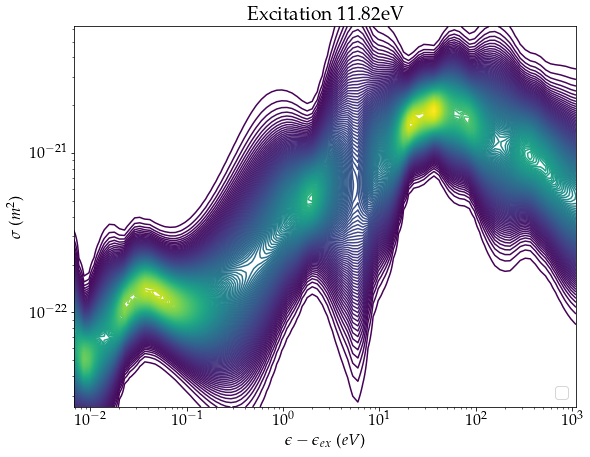

In [241]:
def max_corr(kernels,n,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
#     for k in range(kernels.n):
    varm = kernels.forward(n, xm-xm)
    vart = kernels.forward(n, xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernels.covariance(n,xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

Ntest = 100
xtest = torch.linspace(-5,7,Ntest)
sigmatest = torch.linspace(-3,2.5,Ntest)
maxcor_sum = torch.zeros_like(xtest)
ym, y_var, zm = [], [], []
for k in range(len(Wlog)):
    Kb = cov_kern.forward(k,xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    Kb += torch.diag(ed[k]**2)
    Kp = cov_kern.covariance(k,xm[k],xtest)
    
    LKb = torch.cholesky(Kb)
    ym += [torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()]
    y_cov = cov_kern.covariance(k,xtest,xtest) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    y_var += [torch.diag(y_cov)]
    
    maxcor = max_corr(cov_kern,k,xm[k],xtest)
#     mask = (maxcor<0.3)
#     maxcor[mask] = 0.0
    zm += [maxcor]
    maxcor_sum += zm[k]
    
for zk in zm:
    zk /= maxcor_sum

tm = torch.zeros((Ntest,))
for k in range(len(Wlog)):
    tm += (ym[k] * zm[k])
    
tvar = torch.zeros_like(tm)
for k in range(len(Wlog)):
    tvar += ( y_var[k] + (ym[k] - tm)**2 ) * zm[k]
    
xx, ss = np.meshgrid(xtest.detach(),sigmatest.detach())
pp = np.zeros_like(xx)
for k in range(len(Wlog)):
#     if (k!=0): continue
    yym, tmp = np.meshgrid(ym[k].detach(),sigmatest.detach())
    yyvar, tmp = np.meshgrid(y_var[k].detach(),sigmatest.detach())
    zz, tmp = np.meshgrid(zm[k].detach(),sigmatest.detach())
    
    pp += np.exp( - 0.5 * (ss - yym)**2 / yyvar ) / np.sqrt(2.0 * np.pi * yyvar) * zz
    
ttm, tmp = np.meshgrid(tm.detach(),sigmatest.detach())
ttvar, tmp = np.meshgrid(tvar.detach(),sigmatest.detach())
pp2 = np.exp( - 0.5 * (ss - ttm)**2 / ttvar ) / np.sqrt(2.0 * np.pi *ttvar)
    
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# from matplotlib import cm
# ax.plot_surface(xx, ss, pp,
#                 cmap=cm.coolwarm, linewidth=0)
# ax.view_init(90, -90)
# ax.dist = 5

plt.figure(1)
plt.contour(np.exp(xx),np.exp(ss+float(Wlogm.detach())),pp,200)
for k, wlogk in enumerate(Wlog):
    plt.plot(np.exp(wlogk[:,0]),np.exp(wlogk[:,1]+float(Wlogm.detach())),'x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon - \epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^{2}$)')
plt.title('Excitation 11.82eV')
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset8.pdf", dpi=600)

plt.figure(2)
plt.contour(np.exp(xx),np.exp(ss+float(Wlogm.detach())),pp2,200)
# for k, wlogk in enumerate(Wlog):
#     plt.plot(np.exp(wlogk[:,0]),np.exp(wlogk[:,1]+float(Wlogm.detach())),'x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon - \epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^{2}$)')
plt.title('Excitation 11.82eV')
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset9.pdf", dpi=600)

# temp = np.exp(xx)[:]
# temp.tofile('./xx.dat')
# temp = np.exp(ss + float(Wlogm.detach()))[:]
# temp.tofile('./ss.dat')
# temp = np.exp(pp)[:]
# temp.tofile('./pp.dat')
# temp = np.copy(Wlog[-1][:,:2])
# temp[:,0] = np.exp(temp[:,0])
# temp[:,1] = np.exp(temp[:,1]+float(Wlogm.detach()))
# temp.tofile('./BSR.excite.4.dat')

In [281]:
from models import *

# wcov_inv = np.linalg.inv(wcov)
# wcov_det = np.linalg.det(wcov)

Etest = np.exp(xtest.detach().numpy()) + E_ext[3]
Wm = float(Wlogm.detach())
Ym, Y_var, Zm = [], [], []
for k in range(len(Wlog)):
    Ym += [ym[k].detach().numpy()]
    Y_var += [y_var[k].detach().numpy()]
    Zm += [zm[k].detach().numpy()]

def log_prior_ext4(theta):
#     return 0.0
    if (theta[0]<=0.0):
        return - np.inf
    theta_ref = np.array([2.54e0,1.0,1.0,1.0])
#     theta_ref = np.array([51.2e0,2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[-1] = 0.5
    lp = - 0.5 * np.sum( (theta[:1] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    return lp


def log_likelihood_ext4(theta):
    # compute log-normal probability
#     logModel = np.log( Excite_metastable(level,theta,Etest) )            
    logModel = np.log( Excite_resonance(level,theta,Etest) )
    lk = 0.0
#     for k in range(len(Wlog)):
#         dev = logModel - Wm - Ym[k]
#         lk += np.exp( - 0.5 * dev**2 / Y_var[k] ) / np.sqrt(2.0 * np.pi * Y_var[k]) * Zm[k]

    dev = logModel - Wlogm.detach().numpy() - tm.detach().numpy()
    lk = np.sum( - 0.5 * dev**2 / tvar.detach().numpy() - 0.5 * np.log(2.0*np.pi * tvar.detach().numpy()) )

    return lk

def log_posterior_ext4(theta):
    lp = log_prior_ext4(theta)
    lk = log_likelihood_ext4(theta)
#     print(lp,lk)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

# def log_posterior_ext4(theta, W):
#     lp = log_prior_ext4(theta)
#     lk = 0.0
#     for Wk in W:
#         temp = log_likelihood_ext4(theta, Wk[:,0], Wk[:,1], Wk[:,2])
# #         lk += np.exp(temp)
#         lk += temp
# #     lk = np.log(lk)
#     if (not np.isfinite(lp)) or (not np.isfinite(lk)):
#         return - np.inf
#     return lp + lk


# lk = np.zeros(len(W))
# for k, Wk in enumerate(W):
#     lk[k] = log_likelihood_ext4(theta_ref, Wk[:,0], Wk[:,1], Wk[:,2])
# plt.figure(1)
# plt.plot(lk,'o')

In [282]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e0,1.0,1.0])
# theta_ref = np.array([51.2e0,2.0])
ndim = len(theta_ref)
# pos[:16,0] *= 3.0
pos = theta_ref * (1.0 + 1.0 * np.random.randn(nwalkers,ndim) )
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext4
)

In [283]:
sampler.run_mcmc(pos, 5000, progress=True);
# sampler.run_mcmc(None, 5000, progress=True);

tau = sampler.get_autocorr_time(tol=0)
print(tau)

/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_67432/3321114946.py:29: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance(level,theta,Etest) )
  0%|                                                             | 0/5000 [00:00<?, ?it/s]/opt/homebrew/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:54: RuntimeWarning: overflow encountered in power
  return 4. * np.pi * a0 * a0 * R0 / E * F0 / E_ext[n-1] * rel_factor * ( 1.0 - (E_ext[n-1]/E)**alpha0 ) ** beta
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_67432/3321114946.py:29: RuntimeWarning: divide by zero encountered in log
  logModel = np.log( Excite_resonance(level,theta,Etest) )
100%|█████████████████████████████████████████████████| 5000/5000 [00:05<00:00, 842.44it/s]


[31.13672454 47.31002159 45.54667861]


In [284]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(flat=True)
print(flat_samples.shape)

# tmp = flat_samples,
# tmp.tofile('../crs-Bayes1/crs.excitation.level4.withBSR.modified.dat')

(10464, 3)


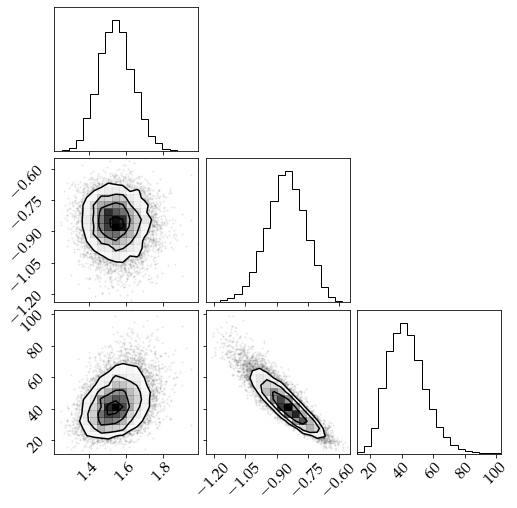

In [290]:
import corner

fig = corner.corner(flat_samples);
fig.savefig("./dataset12.pdf", dpi=600)

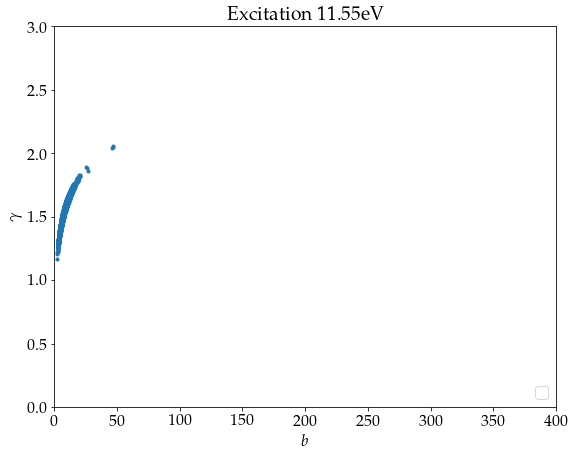

In [257]:
plt.figure(1)
plt.plot(flat_samples[:,0],flat_samples[:,1],'.')
plt.xlim([0, 400])
plt.ylim([0, 3.0])

plt.title('Excitation 11.55eV')
plt.xlabel('$b$')
plt.ylabel('$\gamma$')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset10.pdf", dpi=600)

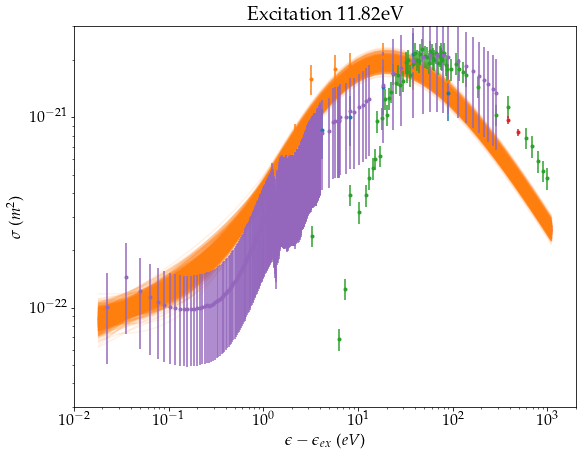

In [291]:
Nw = 50
wtest = np.linspace(-4,7.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_resonance(level,sample,Etest)
#     models = Excite_metastable(level,sample,Etest)
    mask = models > 1.0e-23
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.')
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([3e-23, 3e-21])
plt.xlim([1e-2, 2e3])
plt.title('Excitation 11.82eV')
plt.xlabel('$\epsilon - \epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^{2}$)')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset13.pdf", dpi=600)